# 15 · Capstone: a reproducible BCI experiment

**ROBT613 · Brain–Computer Interfaces** | 6–12 hours

## Goal
Complete a baseline experiment and produce an auditable result table, then extend one paradigm with a predeclared hypothesis.

**Data:** Competition IV 2a baseline; student-selected extension

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: ./mne_data


## Concepts and mathematics

A useful scientific question specifies the population, task, signal, comparison and generalization target. “Does CSP outperform bandpower on a new session of the same participant?” is testable; “build the best BCI” is not a protocol.

Choose one primary metric before testing. For classes with unequal counts, macro recall (balanced accuracy) weights each class equally. For P300, ranking quality and precision–recall can be more informative than raw accuracy. For a complete interface, report selection accuracy and time separately from epoch classification.

Every learned stage—including artifact models, normalization, CSP, feature selection and neural networks—must be fitted only on allowed calibration data. Dataset version and subject/run selection are part of the experiment. A result without its data provenance and split definition cannot be reproduced.

## Run a complete baseline
Use this as a starting experiment, then choose one extension. Keep the held-out session locked while developing it.

Choosing from all possible events


This is nemar-py 0.3.0.
Preparing to download nm000139 from https://data.nemar.org/


Retrieving 5 of 769 manifest files (16 concurrent downloads).
primary backend failed; falling back to next layer: 'README.md' is not annexed (no sha256/md5 checksum on the manifest entry); the S3 backend has nothing to fetch.


Overall:   0%|          | 0.00/12.6k [00:00<?, ?B/s]

Finished downloading nm000139 v1.0.2.
This is nemar-py 0.3.0.
Preparing to download nm000139 from https://data.nemar.org/


...

/home/berdakh/Documents/Codex/2026-09-23/in-berdakh-bci-gan-update-the/work/venv/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
/home/berdakh/Documents/Codex/2026-09-23/in-berdakh-bci-gan-update-the/work/venv/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
/home/berdakh/Documents/Codex/2026-09-23/in-berdakh-bci-gan-update-the/work/venv/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
/home/berdakh/Documents/Codex/2026-09-23/in-berdakh-bci-gan-u

/home/berdakh/Documents/Codex/2026-09-23/in-berdakh-bci-gan-update-the/work/venv/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
/home/berdakh/Documents/Codex/2026-09-23/in-berdakh-bci-gan-update-the/work/venv/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
/home/berdakh/Documents/Codex/2026-09-23/in-berdakh-bci-gan-update-the/work/venv/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
/home/berdakh/Documents/Codex/2026-09-23/in-berdakh-bci-gan-u

/home/berdakh/Documents/Codex/2026-09-23/in-berdakh-bci-gan-update-the/work/venv/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")


col_0   feet  left_hand  right_hand  tongue
row_0                                      
0train    72         72          72      72
1test     72         72          72      72


Held-out session balanced accuracy: 0.7847222222222222


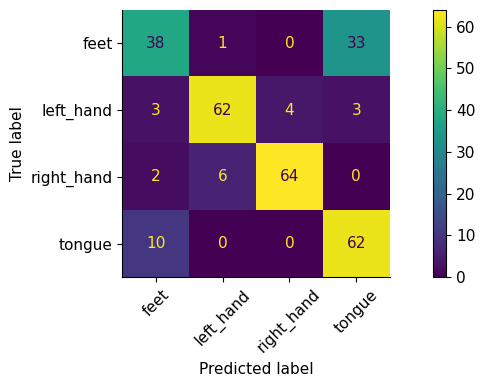

In [2]:
from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery
dataset = BNCI2014_001()
paradigm = MotorImagery(n_classes=4, fmin=8, fmax=30, tmin=0.5, tmax=3.5)
epochs, y, meta = paradigm.get_data(dataset=dataset, subjects=[1], return_epochs=True)
X = epochs.get_data(copy=True)
y = np.asarray(y)
sessions = meta.session.astype(str).to_numpy()
groups = (meta.session.astype(str) + '/' + meta.run.astype(str)).to_numpy()
print(pd.crosstab(sessions, y))
assert len(np.unique(sessions)) == 2
train = sessions == sorted(np.unique(sessions))[0]
test = ~train

from mne.decoding import CSP
model=make_pipeline(CSP(n_components=4,reg='ledoit_wolf',log=True),
                    LinearDiscriminantAnalysis(solver='lsqr',shrinkage='auto'))
model.fit(X[train],y[train])
pred=model.predict(X[test])
score=balanced_accuracy_score(y[test],pred)
print('Held-out session balanced accuracy:',score)
ConfusionMatrixDisplay.from_predictions(y[test],pred,xticks_rotation=45)
plt.tight_layout(); plt.show()

## Export an experiment record
The JSON and table are small derived results; raw datasets remain outside the repository.

In [3]:
import json
record={'dataset':'BNCI2014-001 / BCI Competition IV 2a','subjects':[1],
        'train_sessions':sorted(set(sessions[train])), 'test_sessions':sorted(set(sessions[test])),
        'band_hz':[8,30],'epoch_seconds':[.5,3.5],'seed':SEED,
        'model':'CSP(4, Ledoit-Wolf) + shrinkage LDA',
        'n_train':int(train.sum()),'n_test':int(test.sum()),
        'balanced_accuracy':float(score),
        'versions':{p:metadata.version(p) for p in ['mne','moabb','scikit-learn']}}
out=Path('capstone_results'); out.mkdir(exist_ok=True)
(out/'experiment.json').write_text(json.dumps(record,indent=2))
pd.DataFrame({'truth':y[test],'prediction':pred,'session':sessions[test]}).to_csv(out/'predictions.csv',index=False)
print(json.dumps(record,indent=2))

{
  "dataset": "BNCI2014-001 / BCI Competition IV 2a",
  "subjects": [
    1
  ],
  "train_sessions": [
    "0train"
  ],
  "test_sessions": [
    "1test"
  ],
  "band_hz": [
    8,
    30
  ],
  "epoch_seconds": [
    0.5,
    3.5
  ],
  "seed": 613,
  "model": "CSP(4, Ledoit-Wolf) + shrinkage LDA",
  "n_train": 288,
  "n_test": 288,
  "balanced_accuracy": 0.7847222222222222,
  "versions": {
    "mne": "1.13.2",
    "moabb": "1.7.2",
    "scikit-learn": "1.6.1"
  }
}


## Exercises and checks
**Choose one project:**
1. P300: compare temporal means with a training-fitted spatial ERP method; keep sessions separated.
2. Motor imagery: compare bandpower, CSP/LDA and CNN under one shared protocol.
3. SSVEP: compare window length versus accuracy using fixed reference frequencies.
4. Hybrid proposal: design EEG–fNIRS timing and fusion, including synchronization and a realistic validation plan.

**Submit:** a runnable notebook, split manifest, per-subject results, confusion matrices, preprocessing audit, limitations, and a five-minute demonstration. Report failed experiments and negative results.

**Rubric (100 points):** question and protocol 15; signal-processing rationale 20; leakage-free modeling 25; evaluation and uncertainty 20; reproducibility 10; interpretation and presentation 10.

## Next steps and sources
[Course evaluation guide](../docs/guides/evaluation.md) · [Competition dataset](https://moabb.neurotechx.com/docs/generated/moabb.datasets.BNCI2014_001.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.